# CSE 252B: Computer Vision II, Winter 2026 – Assignment 4

Instructor: Ben Ochoa

Assignment due: Wed, Mar 4, 11:59 PM

**Name:** Evan Cheng

**PID:** A69042831

## Instructions
* Review the academic integrity and collaboration policies on the course
website.
* This assignment must be completed individually.
* All solutions must be written in this notebook.
* Math must be done in Markdown/$\LaTeX$.
* You must show your work and describe your solution.
* Programming aspects of this assignment must be completed using Python in this notebook.
* Your code should be well written with sufficient comments to understand, but there is no need to write extra markdown to describe your solution if it is not explictly asked for.
* This notebook contains skeleton code, which should not be modified (this is important for standardization to facilate efficient grading).
* You may use python packages for basic linear algebra, but you may not use functions that directly solve the problem. If you are uncertain about using a specific package, function, or method, then please ask the instructional staff whether it is allowable.
* **You must submit this notebook as an .ipynb file, a .py file, and a .pdf file on Gradescope.**
    - You may directly export the notebook as a .py file.  You may use [nbconvert](https://nbconvert.readthedocs.io/en/latest/install.html) to convert the .ipynb file to a .py file using the following command
    `jupyter nbconvert --to script filename.ipynb`
    - There are two methods to convert the notebook to a .pdf file.
        - You may first export the notebook as a .html file, then print the web page as a .pdf file.
        - If you have XeTeX installed, then you may directly export the notebook as a .pdf file.  You may use [nbconvert](https://nbconvert.readthedocs.io/en/latest/install.html) to convert a .ipynb file to a .pdf file using the following command
        `jupyter nbconvert --allow-chromium-download --to webpdf filename.ipynb`
    - **You must ensure the contents in each cell (e.g., code, output images, printed results, etc.) are clearly visible, and are not cut off or partially cropped in the .pdf file.**
    - Your code and results must remain inline in the .pdf file (do not move your code to an appendix).
    - **While submitting on gradescope, you must assign the relevant pages in the .pdf file submission for each problem.**
* It is highly recommended that you begin working on this assignment early.

# Problem 1 (Programming): Feature detection (20 points)
Download input data from the course website. The file price_center20.JPG
contains image 1 and the file price_center21.JPG contains image 2.

For each input image, calculate an image where each pixel value is the minor
eigenvalue of the gradient matrix

$$
\mathbf{M} =
\begin{bmatrix}
\sum_x \sum_y \left(R_x^2 + G_x^2 + B_x^2\right)
&
\sum_x \sum_y \left(R_x R_y + G_x G_y + B_x B_y\right)
\\[0.8em]
\sum_x \sum_y \left(R_x R_y + G_x G_y + B_x B_y\right)
&
\sum_x \sum_y \left(R_y^2 + G_y^2 + B_y^2\right)
\end{bmatrix}
$$

$$
\text{where }\;
R_x = \frac{\partial R}{\partial x}, \quad
R_y = \frac{\partial R}{\partial y}, \quad
G_x = \frac{\partial G}{\partial x}, \quad
G_y = \frac{\partial G}{\partial y}, \quad
B_x = \frac{\partial B}{\partial x}, \quad
B_y = \frac{\partial B}{\partial y}.
$$


where $R$, $G$ and $B$ refer to the color channels of the input image, and $x$ and $y$ represent the horizontal and vertical gradient directions respectively. The gradient matrix $M$ is computed over a local window of size $w$. Calculate the gradient images using the five-point
central difference operator. Set resulting values that are below a specified
threshold value to zero (hint: calculating the mean instead of the sum in $M$ allows
for adjusting the size of the window without changing the threshold value). Apply
an operation that suppresses (sets to 0) local (i.e., about a window) nonmaximum
pixel values in the minor eigenvalue image. Vary these parameters such that
600–650 features are detected in each image. For resulting nonzero pixel
values, determine the subpixel feature coordinate using the Förstner corner point
operator.

You may use scipy.signal.convolve to perform convolution operation and scipy.ndimage.maximum_filter for NMS operation.

**Note: You must use the color images (not grayscale) for feature detection; otherwise you will lose points.**

#### Report your final values for:
 * the size of the feature detection window (i.e., the size of the window used to calculate the elements in the gradient matrix $M$)
 * the minor eigenvalue threshold value
 * the size of the local nonmaximum suppression window
 * the resulting number of features detected (i.e., corners) in each image.

#### Display figures for:
 * minor eigenvalue images before thresholding
 * minor eigenvalue images after thresholding
 * original images with detected features

A typical implementation takes around 30 seconds to run. If yours takes more than 120 seconds, you may lose points.

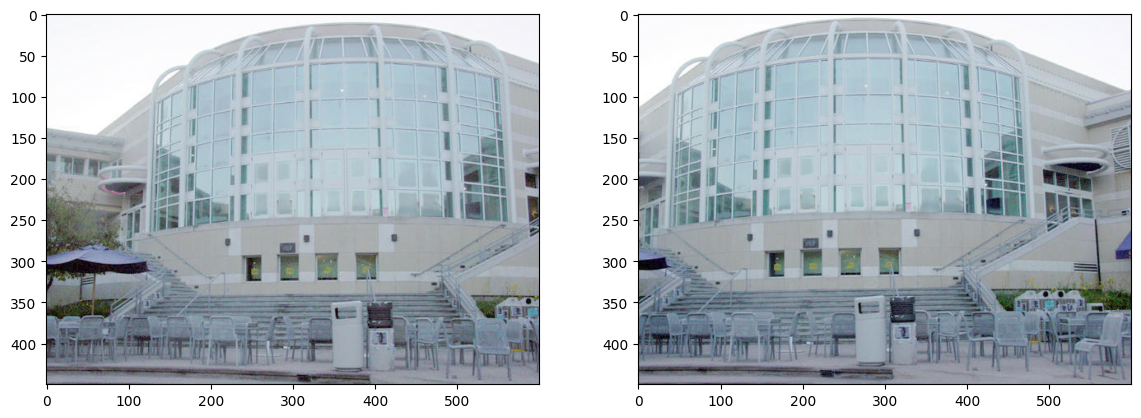

In [41]:
%matplotlib inline
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

# open the input images
I1 = np.array(Image.open('price_center20.JPG'), dtype='float')/255.
I2 = np.array(Image.open('price_center21.JPG'), dtype='float')/255.

# Display the input images
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(I1)
plt.subplot(1,2,2)
plt.imshow(I2)
plt.show()

In [42]:
from scipy import signal
from scipy import ndimage

def image_gradient(I):
    # Calculate the image gradient of I using the 5 point central difference operator
    # inputs:
    # I is the input image (may be mxn for Grayscale or mxnx3 for RGB)
    #
    # outputs:
    # Ix is the derivative of the magnitude of the image w.r.t. x
    # Iy is the derivative of the magnitude of the image w.r.t. y

    m, n = I.shape[:2]

    """your code here"""
    w = np.array([[-1/12, 8/12, 0, -8/12, 1/12]])
    w_t = w.T

    Ix = np.zeros((m, n, 3))
    Iy = np.zeros((m, n, 3))

    #red
    Ix[:,2:-2,0] = signal.convolve(I[:,:,0], w, mode='valid')
    Iy[2:-2,:,0] = signal.convolve(I[:,:,0], w_t, mode='valid')

    #green
    Ix[:,2:-2,1] = signal.convolve(I[:,:,1], w, mode='valid')
    Iy[2:-2,:,1] = signal.convolve(I[:,:,1], w_t, mode='valid')

    #blue
    Ix[:,2:-2,2] = signal.convolve(I[:,:,2], w, mode='valid')
    Iy[2:-2,:,2] = signal.convolve(I[:,:,2], w_t, mode='valid')

    return Ix, Iy


def minor_eigenvalue_image(Ix, Iy, w):
    # Calculate the minor eigenvalue image J
    #
    # inputs:
    # Ix is the derivative of the magnitude of the image w.r.t. x
    # Iy is the derivative of the magnitude of the image w.r.t. y
    # w is the size of the window used to compute the gradient matrix N
    #
    # outputs:
    # J0 is the mxn minor eigenvalue image of N before thresholding

    m, n = Ix.shape[:2]
    J0 = np.zeros((m,n))

    #Calculate your minor eigenvalue image J0.
    """your code here"""
    Rxx = Ix[:,:,0] ** 2
    Gxx = Ix[:,:,1] ** 2
    Bxx = Ix[:,:,2] ** 2

    Rxy = Ix[:,:,0] * Iy[:,:,0]
    Gxy = Ix[:,:,1] * Iy[:,:,1]
    Bxy = Ix[:,:,2] * Iy[:,:,2]

    Ryy = Iy[:,:,0] ** 2
    Gyy = Iy[:,:,1] ** 2
    Byy = Iy[:,:,2] ** 2

    Ixx = Rxx + Gxx + Bxx
    Iyy = Ryy + Gyy + Byy
    Ixy = Rxy + Gxy + Bxy
    
    sum = np.ones((w, w))
    Sxx = signal.convolve(Ixx, sum, mode='same')
    Syy = signal.convolve(Iyy, sum, mode='same')
    Sxy = signal.convolve(Ixy, sum, mode='same')

    detM = Sxx * Syy - Sxy * Sxy
    traceM = Sxx + Syy
    J0 = 0.5 * (traceM - np.sqrt(np.maximum(traceM**2 - 4 * detM, 0)))

    return J0

def nms(J, w_nms):
    # Apply nonmaximum supression to J using window w_nms
    #
    # inputs:
    # J is the minor eigenvalue image input image after thresholding
    # w_nms is the size of the local nonmaximum suppression window
    #
    # outputs:
    # J2 is the mxn resulting image after applying nonmaximum suppression
    #

    J2 = J.copy()
    """your code here"""
    R_max = ndimage.maximum_filter(J, w_nms)
    J2 = np.where(J == R_max, J, 0)

    return J2

def forstner_corner_detector(Ix, Iy, w, t, w_nms):
    # Calculate the minor eigenvalue image J
    # Threshold J
    # Run non-maxima suppression on the thresholded J
    # Gather the coordinates of the nonzero pixels in J
    # Then compute the sub pixel location of each point using the Forstner operator
    #
    # inputs:
    # Ix is the derivative of the magnitude of the image w.r.t. x
    # Iy is the derivative of the magnitude of the image w.r.t. y
    # w is the size of the window used to compute the gradient matrix N
    # t is the minor eigenvalue threshold
    # w_nms is the size of the local nonmaximum suppression window
    #
    # outputs:
    # C is the number of corners detected in each image
    # pts is the 2xC array of coordinates of subpixel accurate corners
    #     found using the Forstner corner detector
    # J0 is the mxn minor eigenvalue image of N before thresholding
    # J1 is the mxn minor eigenvalue image of N after thresholding
    # J2 is the mxn minor eigenvalue image of N after thresholding and NMS

    m, n = Ix.shape[:2]
    J0 = np.zeros((m,n))
    J1 = np.zeros((m,n))

    #Calculate your minor eigenvalue image J0 and its thresholded version J1.
    """your code here"""
    J0 = minor_eigenvalue_image(Ix, Iy, w)
    J1 = np.where(J0 > t, J0, 0)

    #Run non-maxima suppression on your thresholded minor eigenvalue image.
    J2 = nms(J1, w_nms)

    #Detect corners.
    """your code here"""
    y, x = np.where(J2 != 0)
    C = len(x)

    r = w // 2
    pts = []

    for c in range(C):
        i = x[c]
        j = y[c]

        Ix_w = Ix[j-r:j+r+1, i-r:i+r+1, :]
        Iy_w = Iy[j-r:j+r+1, i-r:i+r+1, :]

        X = []
        Y = []

        for x_coord in range(i - r, i + r + 1):
            X.append(x_coord)

        for y_coord in range(j-r, j+r+1):
            Y.append(y_coord)

        X = np.array(X)[None,:]
        Y = np.array(Y)[:,None]

        Rxx = Ix_w[:,:,0] ** 2
        Gxx = Ix_w[:,:,1] ** 2
        Bxx = Ix_w[:,:,2] ** 2

        Rxy = Ix_w[:,:,0] * Iy_w[:,:,0]
        Gxy = Ix_w[:,:,1] * Iy_w[:,:,1]
        Bxy = Ix_w[:,:,2] * Iy_w[:,:,2]

        Ryy = Iy_w[:,:,0] ** 2
        Gyy = Iy_w[:,:,1] ** 2
        Byy = Iy_w[:,:,2] ** 2

        Ixx = Rxx + Gxx + Bxx
        Iyy = Ryy + Gyy + Byy
        Ixy = Rxy + Gxy + Bxy
        
        Sxx = np.sum(Ixx)
        Syy = np.sum(Iyy)
        Sxy = np.sum(Ixy)

        A = np.array([[Sxx, Sxy], [Sxy, Syy]])

        bx = np.sum(X * Ixx + Y * Ixy)
        by = np.sum(X * Ixy + Y * Iyy)
        b = np.array([bx, by])

        corner_x, corner_y = np.linalg.solve(A, b)

        pts.append([corner_x, corner_y])
            
    pts = np.array(pts).T
    C = pts.shape[1]

    return C, pts, J0, J1, J2


# feature detection
def run_feature_detection(I, w, t, w_nms):
    Ix, Iy = image_gradient(I)
    C, pts, J0, J1, J2 = forstner_corner_detector(Ix, Iy, w, t, w_nms)
    return C, pts, J0, J1, J2

In [43]:
# ImageGradient() unit test
def check_values(I, target):
    eps = 1e-8  # Floating point error threshold
    I = I[2:-2, 2:-2]  # Ignore border values
    valid = np.all((I < target + eps) & (I > target - eps))
    print(f'Image is all equal to {target} +/- {eps}: {valid}')

def gray_to_RGB(I):
    h, w = I.shape
    I = np.expand_dims(I, axis=-1)
    return np.broadcast_to(I, (h, w, 3))

rampx = np.array(Image.open('rampx.png'), dtype='float')
rampy = np.array(Image.open('rampy.png'), dtype='float')

rampx = gray_to_RGB(rampx)
rampy = gray_to_RGB(rampy)

# rampx_Ix should be all ones, rampx_Iy should be all zeros (to floating point error)
rampx_Ix, rampx_Iy = image_gradient(rampx)
check_values(rampx_Ix, 1)
check_values(rampx_Iy, 0)

# rampy_Ix should be all zeros, rampx_Iy should be all ones (to floating point error)
rampy_Ix, rampy_Iy = image_gradient(rampy)
check_values(rampy_Ix, 0)
check_values(rampy_Iy, 1)

Image is all equal to 1 +/- 1e-08: True
Image is all equal to 0 +/- 1e-08: True
Image is all equal to 0 +/- 1e-08: True
Image is all equal to 1 +/- 1e-08: True


took 0.182163 secs


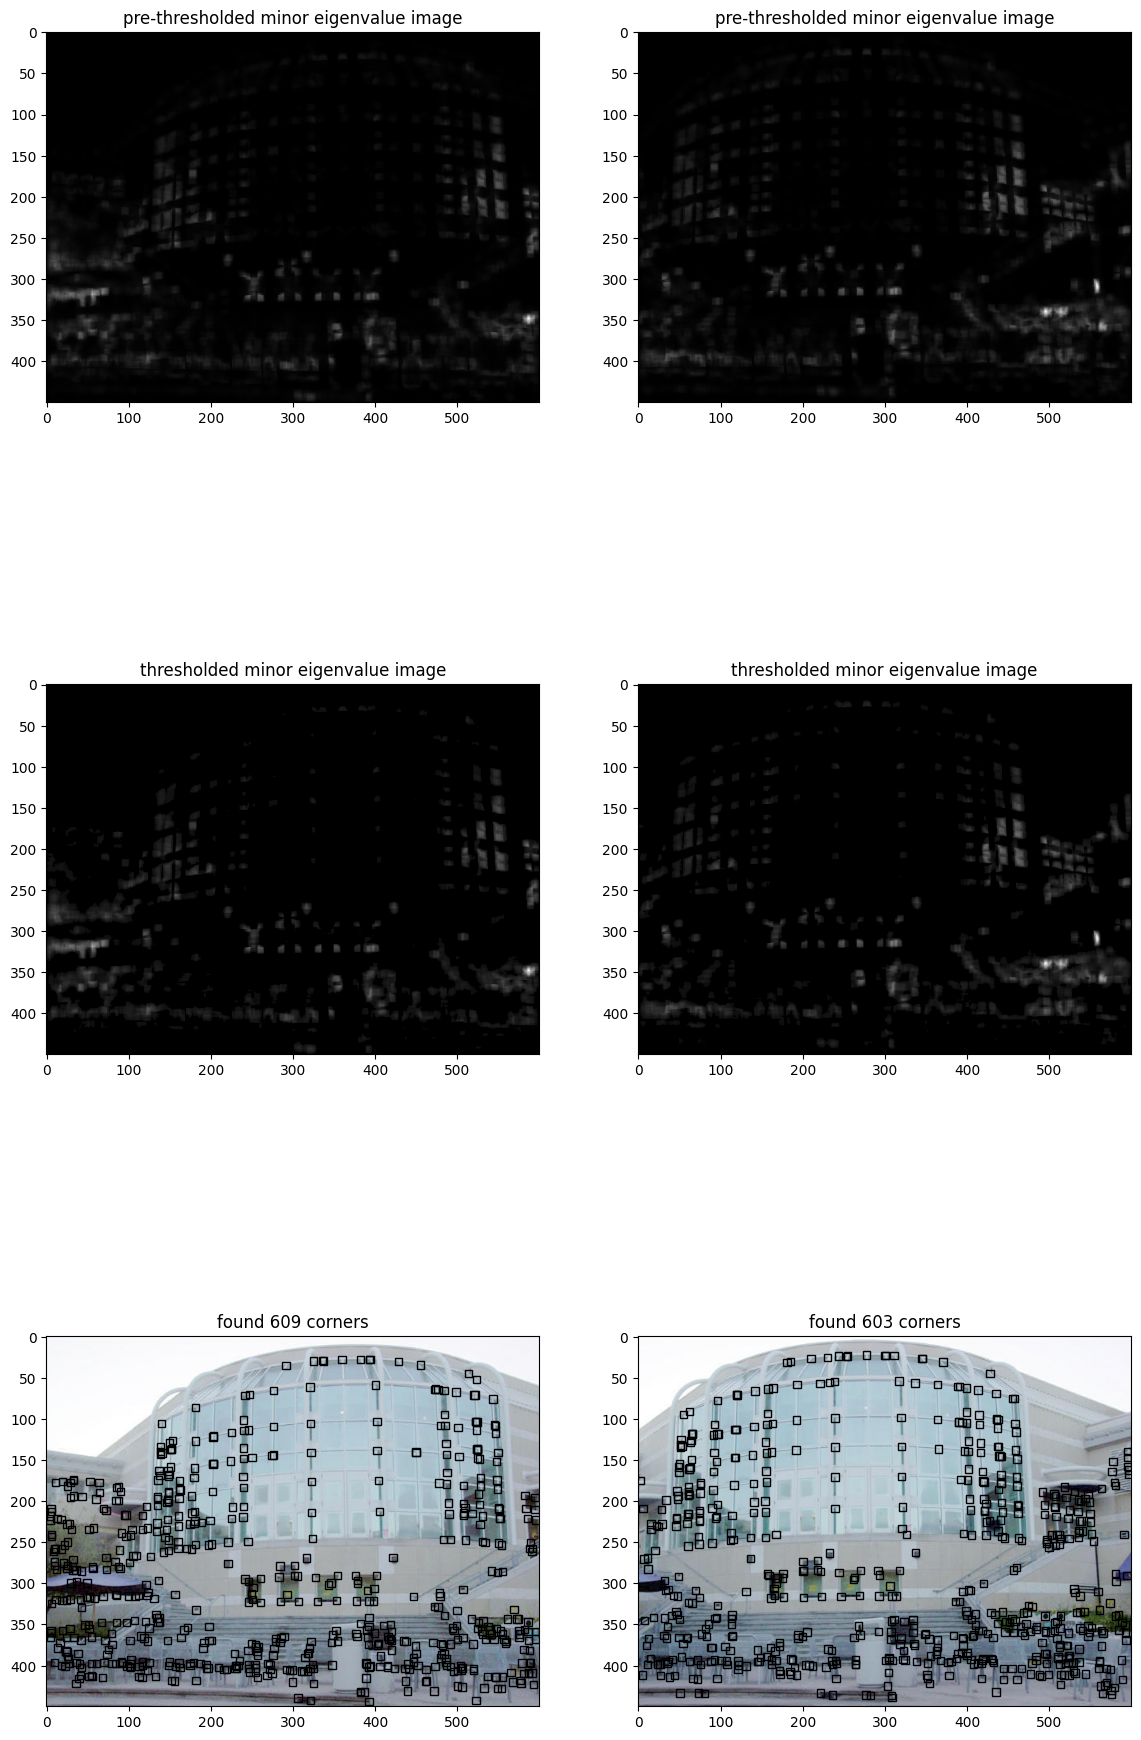

w = 
9
t = 
0.3
w_nms = 
5
C1 = 
609
C2 = 
603


In [44]:
# input images
I1 = np.array(Image.open('price_center20.JPG'), dtype='float')/255.
I2 = np.array(Image.open('price_center21.JPG'), dtype='float')/255.

# parameters to tune
w = 9
t = 0.3
w_nms = 5

tic = time.time()
# run feature detection algorithm on input images
C1, pts1, J1_0, J1_1, J1_2 = run_feature_detection(I1, w, t, w_nms)
C2, pts2, J2_0, J2_1, J2_2 = run_feature_detection(I2, w, t, w_nms)
toc = time.time() - tic

print('took %f secs'%toc)

# display results
plt.figure(figsize=(14,24))

# show pre-thresholded minor eigenvalue images
plt.subplot(3,2,1)
plt.imshow(J1_0, cmap='gray')
plt.title('pre-thresholded minor eigenvalue image')
plt.subplot(3,2,2)
plt.imshow(J2_0, cmap='gray')
plt.title('pre-thresholded minor eigenvalue image')

# show thresholded minor eigenvalue images
plt.subplot(3,2,3)
plt.imshow(J1_1, cmap='gray')
plt.title('thresholded minor eigenvalue image')
plt.subplot(3,2,4)
plt.imshow(J2_1, cmap='gray')
plt.title('thresholded minor eigenvalue image')

# show corners on original images
ax = plt.subplot(3,2,5)
plt.imshow(I1)
for i in range(C1): # draw rectangles of size w around corners
    x,y = pts1[:,i]
    ax.add_patch(patches.Rectangle((x-w/2,y-w/2),w,w, fill=False))
# plt.plot(pts1[0,:], pts1[1,:], '.b') # display subpixel corners
plt.title('found %d corners'%C1)

ax = plt.subplot(3,2,6)
plt.imshow(I2)
for i in range(C2):
    x,y = pts2[:,i]
    ax.add_patch(patches.Rectangle((x-w/2,y-w/2),w,w, fill=False))
# plt.plot(pts2[0,:], pts2[1,:], '.b')
plt.title('found %d corners'%C2)

plt.show()

# final values for parameters
print('w = ')
print(w)
print('t = ')
print(t)
print('w_nms = ')
print(w_nms)
print('C1 = ')
print(C1)
print('C2 = ')
print(C2)

## Problem 2 (Programming): Feature matching (15 points)
Determine the set of one-to-one putative feature correspondences by performing
a brute-force search for the greatest correlation coefficient value (in the range
[-1, 1]) between the detected features in image 1 and the detected features in
image 2. Only allow matches that are above a specified correlation coefficient
threshold value (note that calculating the correlation coefficient allows for adjusting
the size of the matching window without changing the threshold value).
Further, only allow matches that are above a specified distance ratio threshold
value, where distance is measured to the next best match for a given feature.
Vary these parameters such that 160-240 putative feature correspondences are
established. Optional: constrain the search to coordinates in image 2 that are
within a proximity of the detected feature coordinates in image 1. The proximity is calculated using the subpixel coordinates of the detected feature coordinates in image 1 and image 2.  Given $(x_1, y_1)$ in image 1 and $(x_2, y_2)$ in image 2, you can think of a square with side length $p$, centered at $(x_2, y_2)$. Then, $(x_1, y_1)$ is within the proximity window if it lies inside that square.

Use the following formula to calculate the correlation coefficient (normalized cross correlation) between two image windows $w$ in image 1 and $w'$ in image 2:
$$
\gamma = \frac{\sum_x \sum_y \left(w'(x,y) - \bar{w}'\right)\left(w(x,y) - \bar{w}\right)}
{\sqrt{\left( \sum_x \sum_y \left(w'(x,y) - \bar{w}'\right)^2 \right)
\left( \sum_x \sum_y \left(w(x,y) - \bar{w}\right)^2 \right)}},
\quad \gamma \in [-1,1]
$$

For color images:
$$
\gamma = \min(\gamma_R, \gamma_G, \gamma_B)
$$

where $w(x, y)$ is the pixel value of image 1 at $(x, y)$ and $\bar{w}$ is the mean value of the window $w$. Similarly, $w'(x,y)$ and $\bar{w'}$ correspond to pixel values and mean of the window in image 2.

**Note: You must center each window at the sub-pixel corner coordinates while computing normalized cross correlation, i.e., you must use bilinear interpolation to compute the pixel values at non-integer coordinates; Also, perform normalized cross correlation using the color image channels (not grayscale); otherwise, you will lose points.**

#### Report your final values for:
* the size of the matching window
* the correlation coefficient threshold
* the distance ratio threshold
* the size of the proximity window (if used)
* the resulting number of putative feature correspondences (i.e., matched features)

#### Display figures for:
* pair of images, where the matched features in each of the images are indicated by a square window about the feature.

(You must use original (color) images to the draw boxes and correspondence lines)

A typical implementation takes around 10 seconds to run. If yours takes more than 120 seconds, you may lose points.


In [45]:
from scipy.interpolate import RegularGridInterpolator

def bilinear_interpolation(pts,I_single_channel,w):
    # inputs:
    # pts: center points
    # I_single_channel: single channel input image (mxn)
    # w: window size
    #
    # output:
    # Interpolated pixel values for the corner windows

    half_win = w//2
    I_single_channel = np.pad(I_single_channel,pad_width=half_win)
    x = np.linspace(0,I_single_channel.shape[1]-1,I_single_channel.shape[1])
    y = np.linspace(0,I_single_channel.shape[0]-1,I_single_channel.shape[0])
    interp = RegularGridInterpolator((y, x),I_single_channel, bounds_error=False, fill_value=None)

    windows = []

    for c in range(pts.shape[1]):
      xx = np.linspace(pts[0][c]-half_win,pts[0][c]+half_win+1,2*half_win+1)
      yy = np.linspace(pts[1][c]-half_win,pts[1][c]+half_win+1,2*half_win+1)
      X, Y = np.meshgrid(xx, yy, indexing='ij')
      w1 = interp((Y,X))
      windows.append(w1)

    return windows


def compute_ncc(I1, I2, pts1, pts2, w, p):
    # Compute the normalized cross correlation between image patches I1, I2
    # result should be in the range [-1,1]
    #
    # Do ensure that windows are centered at the sub-pixel co-ordinates
    #      while computing normalized cross correlation.
    #
    # inputs:
    # I1, I2 are the input images
    # pts1, pts2 are the point to be matched
    # w is the size of the matching window to compute correlation coefficients
    # p is the size of the proximity window
    #
    # output:
    # normalized cross correlation matrix of scores between all windows in
    #    image 1 and all windows in image 2
    #

    """your code here"""
    scores = np.zeros((pts1.shape[1], pts2.shape[1]))
    w1 = [None] * 3
    w2 = [None] * 3

    #bilinear interpolation for RGB channels
    for c in range(3):
        w1[c] = bilinear_interpolation(pts1, I1[:,:,c], w)
        w2[c] = bilinear_interpolation(pts2, I2[:,:,c], w)

    for i in range(pts1.shape[1]):
        pt1 = pts1[:, i]
        for j in range(pts2.shape[1]):
            pt2 = pts2[:, j]
            
            #check proximity
            distance = np.sqrt((pt1[0] - pt2[0])**2 + (pt1[1] - pt2[1])**2)
            if distance > p:
                scores[i, j] = -np.inf
                continue
            
            ncc = np.zeros((3))

            #ncc for RGB channels
            for c in range(3):
                w_i = w1[c][i]
                w_j = w2[c][j]

                mean_i = np.mean(w_i)
                mean_j = np.mean(w_j)

                num = np.sum((w_j - mean_j) * (w_i - mean_i))
                denom = np.sqrt(np.sum((w_j - mean_j)**2) * np.sum((w_i - mean_i)**2))
                
                if denom != 0:
                    ncc[c] = num / denom
                else:
                    ncc[c] = 0                    

            scores[i, j] = np.min(ncc)

    return scores


def perform_match(scores, t, d):
    # Perform the one-to-one correspondence matching on the correlation coefficient matrix
    #
    # inputs:
    # scores is the NCC matrix
    # t is the correlation coefficient threshold
    # d distance ration threshold
    #
    # output:
    # 2xM array of the feature coordinates in image 1 and image 2,
    # where M is the number of matches.

    """your code here"""
    inds = []

    m, n = scores.shape
    mask = np.ones((m, n), dtype=bool)
    
    masked_scores = np.where(mask, scores, -np.inf)

    while np.max(masked_scores) >= t:
        max_val = -np.inf
        i, j = 0, 0

        #1. find max and max index
        for row in range(m):
            for col in range(n):
                if masked_scores[row, col] > max_val:
                    max_val = masked_scores[row, col]
                    i, j = row, col

        #2. store best
        best = scores[i, j]

        #3. temporarily set to -1
        scores[i, j] = -1

        #4. find next best in row/col
        row_max = np.max(scores[i, :])
        col_max = np.max(scores[:, j])
        second_best = max(row_max, col_max)

        #5. set max value back to original value
        scores[i, j] = best

        #6. check unique
        if (1 - best) < (1 - second_best) * d:
            inds.append((i, j))

        #7. set best match row/col to false
        mask[i, :] = False
        mask[:, j] = False
        
        masked_scores = np.where(mask, scores, -np.inf)

    inds = np.array(inds).T

    return inds



def run_feature_matching(I1, I2, pts1, pts2, w, t, d, p):
    # Run the feature matching algorithm
    # inputs:
    # I1, I2 are the input images
    # pts1, pts2 are the point to be matched
    # w is the size of the matching window to compute correlation coefficients
    # t is the correlation coefficient threshold
    # d distance ration threshold
    # p is the size of the proximity window
    #
    # outputs:
    # inds is a 2xk matrix of matches where inds[0,i] indexs a point pts1
    #     and inds[1,i] indexs a point in pts2, where k is the number of matches

    scores = compute_ncc(I1, I2, pts1, pts2, w, p)
    inds = perform_match(scores, t, d)
    return inds

took 30.036796 secs


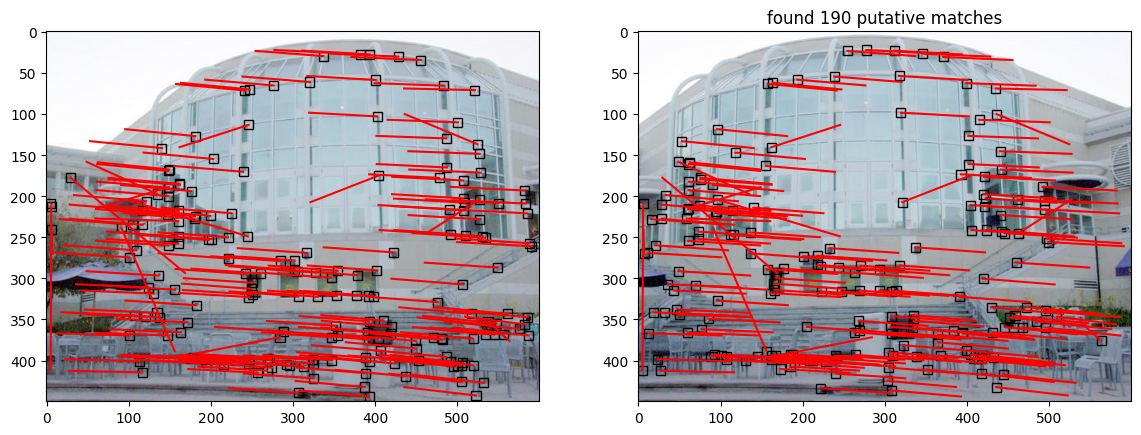

unique points in image 1: 190
unique points in image 2: 190
w = 
11
t = 
0.6
d = 
0.8
p = 
200


In [46]:
# parameters to tune
w = 11
t = 0.6
d = 0.8
p = 200

tic = time.time()
# run the feature matching algorithm on the input images and detected features
inds = run_feature_matching(I1, I2, pts1, pts2, w, t, d, p)
toc = time.time() - tic

print('took %f secs'%toc)

# create new matrices of points which contain only the matched features
match1 = pts1[:,inds[0,:].astype('int')]
match2 = pts2[:,inds[1,:].astype('int')]

# display the results
plt.figure(figsize=(14,24))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
ax1.imshow(I1)
ax2.imshow(I2)
plt.title('found %d putative matches'%match1.shape[1])
for i in range(match1.shape[1]):
    x1,y1 = match1[:,i]
    x2,y2 = match2[:,i]
    ax1.plot([x1, x2],[y1, y2],'-r')
    ax1.add_patch(patches.Rectangle((x1-w/2,y1-w/2),w,w, fill=False))
    ax2.plot([x2, x1],[y2, y1],'-r')
    ax2.add_patch(patches.Rectangle((x2-w/2,y2-w/2),w,w, fill=False))

plt.show()

# test 1-1
print('unique points in image 1: %d'%np.unique(inds[0,:]).shape[0])
print('unique points in image 2: %d'%np.unique(inds[1,:]).shape[0])

# final values for parameters
print('w = ')
print(w)
print('t = ')
print(t)
print('d = ')
print(d)
print('p = ')
print(p)

## Problem 3 (Programming): Outlier Rejection (15 points)
The resulting set of putative point correspondences should contain both inlier
and outlier correspondences (i.e., false matches). Determine the set of inlier point
correspondences using the M-estimator Sample Consensus (MSAC) algorithm,
where the maximum number of attempts to find a consensus set is determined
adaptively. For each trial, you must use the 4-point algorithm (as described in
lecture) to solve for the planar projective transformation from the 2D points in
image 1 to the 2D points in image 2. Calculate the (squared) Sampson error as a
first order approximation to the geometric error. There must be at least **150 inlier correspondences**.

hint: this problem has codimension 2

#### Report your values for:
 * the probability $p$ that as least one of the random samples does not contain any outliers
 * the probability $\alpha$ that a given point is an inlier
 * the resulting number of inliers
 * the number of attempts to find the consensus set
 * the tolerance for inliers
 * the cost threshold

#### Display figures for:
* pair of images, where the inlier features in each of the images are indicated by a square window about the feature and a line segment is drawn from the feature to the coordinates of the corresponding feature in the other image


took 0.051397 secs
10 iterations
inlier count:  172
inliers:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 75, 76, 77, 78, 79, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 133, 134, 135, 136, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 182, 183, 186, 188]
MSAC Cost=226.306529684
H_MSAC =
[[ 1.14661360e-02 -1.32000203e-04 -9.86660983e-01]
 [ 2.78206582e-04  1.11651360e-02 -1.61631488e-01]
 [ 1.13626722e-06 -3.36846607e-07  1.09151078

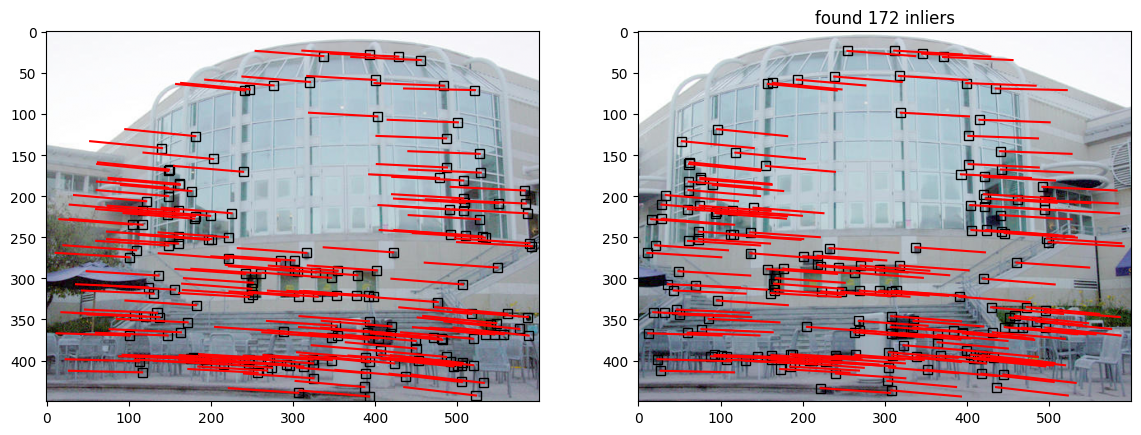

p = 
0.99
alpha = 
0.95
tolerance = 
5.991464547107979
threshold = 
100
num_inliers = 
172
num_attempts = 
10


In [47]:
from scipy.stats import chi2

def display_results(H, title):
    print(title+' =')
    print (H/np.linalg.norm(H)*np.sign(H[-1,-1]))

def homogenize(x):
    # Converts points from inhomogeneous to homogeneous coordinates
    return np.vstack((x,np.ones((1,x.shape[1]))))

def dehomogenize(x):
    # Converts points from homogeneous to inhomogeneous coordinates
    return x[:-1]/x[-1]

def compute_MSAC_cost(H,x1,x2,tol):
    # Compute the MSAC cost
    # Inputs:
    # x1 - 2D points in image 1
    # x2 - 2D points in image 2
    # H - planar projective transformation matrix
    # tol - tolerance for establishing datum/model compatibility
    #
    # Output:
    # cost - Squared sampson error
    """your code here"""
    x_t = x1[0]
    y_t = x1[1]
    x_t_p = x2[0]
    y_t_p = x2[1]

    sum = 0
    for i in range(x_t.shape[0]):
        epsilon = np.array([[-(x_t[i]*H[1,0] + y_t[i]*H[1,1] + H[1,2]) + y_t_p[i] * (x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2])],
                            [x_t[i]*H[0,0] + y_t[i]*H[0,1] + H[0,2] - x_t_p[i] * (x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2])]])
        
        J = np.array([[-H[1,0] + y_t_p[i]*H[2,0], -H[1,1] + y_t_p[i]*H[2,1], 0, x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2]],
                      [H[0,0] - x_t_p[i]*H[2,0], H[0,1] - x_t_p[i]*H[2,1], -(x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2]), 0]])
        
        sum += np.minimum(epsilon.T @ np.linalg.inv(J @ J.T) @ epsilon, tol)

    cost = sum[0][0]
    return cost

def determine_inliers(pts1, pts2, thresh, tol, p):
    # Determine the inliers using the MSAC algorithm
    # Inputs:
    #    pts1 - matched feature correspondences in image 1
    #    pts2 - matched feature correspondences in image 2
    #    thresh - cost threshold
    #    tol - reprojection error tolerance
    #    p - probability that as least one of the random samples does not contain any outliers
    #
    # Output:
    #    consensus_min_cost - final cost from MSAC
    #    consensus_min_cost_model - planar projective transformation matrix H
    #    inliers - list of indices of the inliers corresponding to input data
    #    trials - number of attempts taken to find consensus set

    """your code here"""



    trials = 0
    max_trials = 1000
    consensus_min_cost = np.inf
    consensus_min_cost_model = np.zeros((3, 3))
    inliers = []

    while (trials < max_trials and consensus_min_cost > thresh):
        sample_i = np.random.choice(pts1.shape[1], 4, replace=False)
        x1 = pts1[:, sample_i]
        x2 = pts2[:, sample_i]
   
        x1 = homogenize(x1)
        x2 = homogenize(x2)

        def points_to_HSB_inv(pts):
            A = pts[:, :3]
            b = pts[:, 3]
            lam = np.linalg.solve(A, b)
            HSB_inv = A * lam
            return HSB_inv

        HSB_inv = points_to_HSB_inv(x1)
        HSB_p_inv = points_to_HSB_inv(x2)

        H = HSB_p_inv @ np.linalg.inv(HSB_inv)

        if H is None:
            trials += 1
            continue

        #calculate cost
        cost = compute_MSAC_cost(H, pts1, pts2, tol)
        
        #if cost bettter, calculate number of inliers, w, max trials
        if cost < consensus_min_cost:
            consensus_min_cost = cost
            consensus_min_cost_model = H

            proj2 = dehomogenize(H @ homogenize(pts1))
            proj1 = dehomogenize(np.linalg.inv(H) @ homogenize(pts2))
            errors = np.sum((pts1 - proj1)**2, axis=0) + np.sum((pts2 - proj2)**2, axis=0)
            num_inliers = np.sum(errors <= tol**2)
            
            w = num_inliers / pts1.shape[1]
            if w > 0 and w < 1:
                max_trials = np.log(1 - p) / np.log(1 - w**4)

        trials += 1

        if trials > 100:
            break

    #calculate error of each point using consensus_min_cost_model and set of inliers
    if consensus_min_cost < np.inf:
        proj2 = dehomogenize(consensus_min_cost_model @ homogenize(pts1))
        proj1 = dehomogenize(np.linalg.inv(consensus_min_cost_model) @ homogenize(pts2))
        errors = np.sum((pts1 - proj1)**2, axis=0) + np.sum((pts2 - proj2)**2, axis=0)
        inliers = np.where(errors <= tol**2)[0].tolist()
    else:
        inliers = []

    return consensus_min_cost, consensus_min_cost_model, inliers, trials


# MSAC parameters
thresh = 100
tol = chi2.ppf(0.95, df=2)
p = 0.99
alpha = 0.95

tic=time.time()

cost_MSAC, H_MSAC, inliers, trials = determine_inliers(match1, match2, thresh, tol, p)

# choose just the inliers
xin1 = match1[:,inliers]
xin2 = match2[:,inliers]

toc=time.time()
time_total=toc-tic

# display the results
print('took %f secs'%time_total)
print('%d iterations'%trials)
print('inlier count: ',len(inliers))
print('inliers: ',inliers)
print('MSAC Cost=%.9f'%cost_MSAC)
display_results(H_MSAC, 'H_MSAC')

# display the figures
plt.figure(figsize=(14,24))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
ax1.imshow(I1)
ax2.imshow(I2)
plt.title('found %d inliers'%xin1.shape[1])
for i in range(xin1.shape[1]):
    x1,y1 = xin1[:,i]
    x2,y2 = xin2[:,i]
    ax1.plot([x1, x2],[y1, y2],'-r')
    ax1.add_patch(patches.Rectangle((x1-w/2,y1-w/2),w,w, fill=False))
    ax2.plot([x2, x1],[y2, y1],'-r')
    ax2.add_patch(patches.Rectangle((x2-w/2,y2-w/2),w,w, fill=False))

plt.show()

# display the results
print('p = ')
print(p)
print('alpha = ')
print(alpha)
print('tolerance = ')
print(tol)
print('threshold = ')
print(thresh)
print('num_inliers = ')
print(len(inliers))
print('num_attempts = ')
print(trials)

## Problem 4 (Programming): Linear Estimate (15 points)
  Estimate the planar projective transformation $\mathtt{H}_\text{DLT}$
  from the resulting set of inlier correspondences using the direct
  linear transformation (DLT) algorithm (with data normalization).
  You must express $\boldsymbol{\mathrm{x}}'_i = \mathtt{H} \boldsymbol{\mathrm{x}}_i$ as
  $[\boldsymbol{\mathrm{x}}'_i]^\perp \mathtt{H} \boldsymbol{\mathrm{x}}_i = \boldsymbol{0}$ (not
  $\boldsymbol{\mathrm{x}}'_i \times \mathtt{H} \boldsymbol{\mathrm{x}}_i = \boldsymbol{0}$), where
  $[\boldsymbol{\mathrm{x}}'_i]^\perp \boldsymbol{\mathrm{x}}'_i = \boldsymbol{0}$, when forming the
  solution. Return $\mathtt{H}_\text{DLT}$, scaled such that
  $\lVert\mathtt{H}_\text{DLT}\rVert_\text{Fro} = 1$

In [48]:
def data_normalize(pts):
    # Input:
    # pts - 2D scene points
    # Outputs:
    # pts - data normalized points
    # T - corresponding transformation matrix

    """your code here"""

    T = np.eye(pts.shape[0] + 1)

    mu_x = np.mean(pts[0])
    mu_y = np.mean(pts[1])

    var_x = np.var(pts[0])
    var_y = np.var(pts[1])

    s = np.sqrt(2 / (var_x + var_y))

    T[:2,:2] *= s
    T[0,2] = -s * mu_x
    T[1,2] = -s * mu_y

    pts = homogenize(pts)
    pts = T @ pts

    return pts, T

def compute_sampson_cost(H,x1,x2):
    # Compute the Sampson cost for a given homography and matched point correspondences
    # Inputs:
    # x1 - 2D points in image 1
    # x2 - 2D points in image 2
    # H - planar projective transformation matrix
    #
    # Output:
    # cost - Squared sampson error
    """your code here"""
    x_t = x1[0]
    y_t = x1[1]
    x_t_p = x2[0]
    y_t_p = x2[1]

    sum = 0
    for i in range(x_t.shape[0]):
        epsilon = np.array([[-(x_t[i]*H[1,0] + y_t[i]*H[1,1] + H[1,2]) + y_t_p[i] * (x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2])],
                            [x_t[i]*H[0,0] + y_t[i]*H[0,1] + H[0,2] - x_t_p[i] * (x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2])]])
        
        J = np.array([[-H[1,0] + y_t_p[i]*H[2,0], -H[1,1] + y_t_p[i]*H[2,1], 0, x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2]],
                      [H[0,0] - x_t_p[i]*H[2,0], H[0,1] - x_t_p[i]*H[2,1], -(x_t[i]*H[2,0] + y_t[i]*H[2,1] + H[2,2]), 0]])
        
        sum += (epsilon.T @ np.linalg.inv(J @ J.T) @ epsilon)[0,0]

    cost = sum
    return cost

def estimate_2D_projective_transformation_linear(x1, x2, normalize=True):
    # Estimate the planar projective transformation using the DLT algorithm
    # Inputs:
    #    x1 - inhomogeneous inlier correspondences in image 1
    #    x2 - inhomogeneous inlier correspondences in image 2
    #    normalize - if True, apply data normalization to x1 and x2
    #
    # Outputs:
    #    H - the DLT estimate of the planar projective transformation
    #    cost - Sampson cost for the above DLT Estimate H. Assume points in image 1 as scene points.

    """your code here"""

    # data normalization
    if normalize:
        print('normalize')
        x1_DN, T = data_normalize(x1)
        x2_DN, T_p = data_normalize(x2)
    else:
        x1_DN = homogenize(x1)
        x2_DN = homogenize(x2)
    
    A = []

    for i in range(x1_DN.shape[1]):
        x = x1_DN[:,i]
        x_p = x2_DN[:,i]

        x_p_lines = np.array([[1, 0, -x_p[0]],
                              [0, 1, -x_p[1]]])
        A.append(np.kron(x_p_lines, x.reshape(1,3)))

    A = np.vstack(A)

    _, _, V_T = np.linalg.svd(A)
    h = V_T[-1]

    H_DN = h.reshape(3,3)

    # data denormalize
    if normalize:
        print('denormalize')
        H = np.linalg.inv(T_p) @ H_DN @ T
    else:
        H = H_DN

    H = H / np.linalg.norm(H, 'fro')
    cost = compute_sampson_cost(H, x1, x2)
    return H, cost


# compute the linear estimate without data normalization
print('Running DLT without data normalization')
time_start=time.time()
H_DLT,cost = estimate_2D_projective_transformation_linear(xin1, xin2, normalize=False)
time_total=time.time()-time_start
# display the results
print('took %f secs'%time_total)
print('Cost=%.9f'%cost)


# compute the linear estimate with data normalization
print ('Running DLT with data normalization')
time_start=time.time()
H_DLT, cost = estimate_2D_projective_transformation_linear(xin1, xin2, normalize=True)
time_total=time.time()-time_start
# display the results
print('took %f secs'%time_total)
print('Cost=%.9f'%cost)

# display your H_DLT, scaled with its frobenius norm
display_results(H_DLT, 'H_DLT')

Running DLT without data normalization
took 0.008703 secs
Cost=30.853920005
Running DLT with data normalization
normalize
denormalize
took 0.012410 secs
Cost=30.790016843
H_DLT =
[[ 1.10192984e-02 -2.10697768e-05 -9.85332640e-01]
 [ 3.06521015e-04  1.07393520e-02 -1.69636552e-01]
 [ 1.20233178e-06  7.34592341e-08  1.03041738e-02]]


## Problem 5 (Programming): Nonlinear Estimate (45 points)
 Use $\mathtt{H}_\text{DLT}$ and the Sampson corrected points (in image 1) as an initial estimate to an iterative estimation method,
  specifically the sparse Levenberg-Marquardt algorithm, to
  determine the Maximum Likelihood estimate of the planar projective
  transformation that minimizes the reprojection error.  You must
  parameterize the planar projective transformation matrix and the
  homogeneous 2D scene points that are being adjusted using the
  parameterization of homogeneous vectors.
  
  Report the initial cost (i.e. cost at iteration 0) and the cost at the end
  of each successive iteration. Show the numerical values for the final
  estimate of the planar projective transformation matrix $\mathtt{H}_\text{LM}$, scaled
  such that $\lVert\mathtt{H}_\text{LM}\rVert_\text{Fro} = 1$.

In [80]:
# Note that np.sinc is different than defined in class
def sinc(x):
    # Returns a scalar valued sinc value
    """your code here"""
    if x == 0: 
        y = 1
    else:
        y = np.sin(x) / x

    return y

def d_sinc(x):

    """your code here"""
    if x == 0:
        y = 0
    else:
        y = (np.cos(x) / x) - (np.sin(x) / x**2)

    return y

def parameterize_matrix(P):
    # Wrapper function to interface with LM
    # takes all optimization variables and parameterizes all of them

    return parameterize_homog(P.reshape(-1,1))

def deparameterize_matrix(m,rows,columns):
    # Deparameterize all optimization variables
    # Input:
    #   m - matrix to be deparameterized
    #   rows - number of rows of the deparameterized matrix
    #   columns - number of rows of the deparameterized matrix
    #
    # Output:
    #    deparameterized matrix

    return deparameterize_homog(m).reshape(rows,columns)

def parameterize_homog(v_bar):
    # Given a homogeneous vector v_bar return its minimal parameterization
    """your code here"""
    a = v_bar[0]
    b = v_bar[1:]

    v = 2 / (sinc(np.arccos(a))) * b

    norm = np.linalg.norm(v)
    v = (1 - (2 * np.pi / norm) * np.ceil((norm - np.pi) / (2 * np.pi))) * v

    return v

def deparameterize_homog(v):
    # Given a parameterized homogeneous vector return its deparameterization
    """your code here"""
    norm = np.linalg.norm(v)

    a = np.cos(norm / 2)
    b = (sinc(norm / 2) / 2) * v

    a = np.array([[a]])
    b = b.reshape(-1,1)
    v_bar = np.vstack((a, b))

    return v_bar

def partial_vbar_partial_v(v):
    # Compute the derivative of the deparameterization of a homogeneous vector w.r.t its parameterization
    # Input:
    # v - homogeneous parameterization vector
    # Output:
    # d_vbar_d_v - derivative of vbar w.r.t v

    """your code here"""
    d_vbar_d_v = np.zeros((9,8))
    norm = np.linalg.norm(v)
    
    a = np.cos(norm / 2)
    b = (sinc(norm / 2) / 2) * v

    if norm == 0:
        partial_a = np.zeros((1,8))
        partial_b = 0.5 * np.eye(8)
    else:
        partial_a = -0.5 * b.T
        partial_b = (sinc(norm/2) * 0.5) * np.eye(8) + ((1/(4*norm)) * d_sinc(norm/2) * (v @ v.T))

    d_vbar_d_v[0] = partial_a
    d_vbar_d_v[1:] = partial_b

    return d_vbar_d_v

def partial_xhat_partial_hbar(H,x):
    # Mapping deparameterized scene point to the second image under the deparameterized second 2D projective transformation matrix
    # Input:
    # H - 2D projective transformation matrix (3x3)
    # x - deparameterized scene point (3x1)
    # Output:
    # d_xhat_d_hbar - derivative of xhat w.r.t hbar (2x9)

    """your code here"""
    d_xhat_d_hbar = np.zeros((2,9))

    w_p = H[2,:] @ x
    x_t = dehomogenize(H @ x)

    x_T = x.reshape(1,3)

    d_xhat_d_hbar[:,:] = (1/w_p) * np.block([[x_T, np.zeros((1,3)), -x_t[0] * x_T],
                                             [np.zeros((1,3)), x_T, -x_t[1] * x_T]])

    return d_xhat_d_hbar

def partial_xhat_partial_xbar(H,x):
    # Map the deparameterized scene point to the first/second image under the first/second 2D projective transformation matrix
    # Input:
    # H - 2D projective transformation matrix (3x3)
    # x - deparameterized scene point (3x1)
    # Output:
    # d_xhat_d_xbar - derivative of xhat w.r.t xbar (2x3)

    """your code here"""
    d_xhat_d_xbar = np.zeros((2,3))

    w_p = H[2,:] @ x
    x_t = dehomogenize(H @ x)

    d_xhat_d_xbar[:,:] = (1/w_p) * np.block([[H[0,:] - x_t[0]*H[2,:]],
                                             [H[1,:] - x_t[1]*H[2,:]]])

    return d_xhat_d_xbar

def data_normalize_with_cov(pts, covarx):
    # Data normalization of n dimensional pts
    #
    # Input:
    # pts - is in inhomogeneous coordinates
    # covarx - covariance matrix associated with x. Has size 2n x 2n, where n is number of points.
    # Outputs:
    # pts - data normalized points
    # T - corresponding transformation matrix
    # covarx - normalized covariance matrix
    """your code here"""
    s = np.sqrt(2 / np.sum(np.var(pts, axis=1)))
    mu = np.mean(pts, axis=1)

    T = np.eye(pts.shape[0]+1)
    T[0:2,0:2] *= s
    T[0:2,2] = -s * mu

    pts = homogenize(pts)
    pts = T @ pts

    J = s * np.eye(2)
    covarx = np.einsum('ij,jkn,lk->iln', J, covarx, J)

    return pts, T, covarx

def compute_cost(x1,x2,scene_pts,H,cov1,cov2):
    # Inputs:
    # x1 - 2D points in image 1
    # x2 - 2D points in image 2
    # scene_pts - 3D scene points
    # H - 2D projective transformation matrix (3x3)
    # cov1 - covariance matrix associated with points in image 1
    # cov2 - covariance matrix associated with points in image 2
    #
    # Output:
    # cost - total error
    """your code here"""
    cost = 0
    n = x1.shape[1]
    
    for i in range(n):
        x1_h = dehomogenize(scene_pts[:, i])
        x2_h = dehomogenize(H @ scene_pts[:, i])

        eps1 = x1[:, i] - x1_h
        eps2 = x2[:, i] - x2_h

        cost += eps1 @ np.linalg.inv(cov1[:, :, i]) @ eps1
        cost += eps2 @ np.linalg.inv(cov2[:, :, i]) @ eps2
    return cost

In [76]:
# Unit Tests (Do not change)

def check_values_jacobian():
    eps = 1e-5  # Floating point error threshold
    x_scene_hat = np.load('unit_test/scene_point_parameterized.npy')
    h_hat = np.load('unit_test/H_parameterized.npy')

    d_hbar_d_hhat_target  = np.load('unit_test/d_hbar_d_hhat.npy')
    d_xhat_d_hbar_target  = np.load('unit_test/d_xhat_d_hbar.npy')
    d_xhat1_d_xbar_target = np.load('unit_test/d_xhat1_d_xbar.npy')
    d_xhat2_d_xbar_target = np.load('unit_test/d_xhat2_d_xbar.npy')

    d_hbar_d_hhat  = partial_vbar_partial_v(h_hat)
    d_xhat_d_hbar  = partial_xhat_partial_hbar(deparameterize_matrix(h_hat,3,3),deparameterize_homog(x_scene_hat))
    d_xhat1_d_xbar = partial_xhat_partial_xbar(np.eye(3),deparameterize_homog(x_scene_hat))
    d_xhat2_d_xbar = partial_xhat_partial_xbar(deparameterize_matrix(h_hat,3,3),deparameterize_homog(x_scene_hat))

    d_hbar_d_hhat_valid = np.all(np.abs(d_hbar_d_hhat - d_hbar_d_hhat_target) < eps)
    d_xhat_d_hbar_valid = np.all(np.abs(d_xhat_d_hbar - d_xhat_d_hbar_target) < eps)
    d_xhat1_d_xbar_valid = np.all(np.abs(d_xhat1_d_xbar - d_xhat1_d_xbar_target) < eps)
    d_xhat2_d_xbar_valid = np.all(np.abs(d_xhat2_d_xbar - d_xhat2_d_xbar_target) < eps)

    print(f'Computed partial_hbar_partial_h is equal to the given value +/- {eps}: {d_hbar_d_hhat_valid}')
    print(f'Computed partial_xhat_partial_hbar is equal to the given value +/- {eps}: {d_xhat_d_hbar_valid}')
    print(f'Computed partial_xhat_partial_xbar is equal to the given value +/- {eps}: {d_xhat1_d_xbar_valid}')
    print(f'Computed partial_xhat\'_partial_xbar is equal to the given value +/- {eps}: {d_xhat2_d_xbar_valid}')

check_values_jacobian()

Computed partial_hbar_partial_h is equal to the given value +/- 1e-05: True
Computed partial_xhat_partial_hbar is equal to the given value +/- 1e-05: True
Computed partial_xhat_partial_xbar is equal to the given value +/- 1e-05: True
Computed partial_xhat'_partial_xbar is equal to the given value +/- 1e-05: True


In [83]:
def estimate_2D_projective_transformation_non_linear(H, x1, x2, max_iters, lam):
    # Estimate the planar projective transformation using the LM algorithm
    # Input:
    #    H - Initial estimate of planar projective transformation matrix
    #    x1 - inhomogeneous inlier points in image 1
    #    x2 - inhomogeneous inlier points in image 2
    #    max_iters - maximum number of iterations
    #    lam - lambda parameter
    # Output:
    #    H - Final H (3x3) obtained after convergence

    # data normalization

    n_points = x1.shape[1]
    """your code here"""
    tau_1 = 1e-7
    tau_2 = 0

    cov1 = np.repeat(np.eye(2)[:, :, np.newaxis], n_points, axis=2)
    cov2 = np.repeat(np.eye(2)[:, :, np.newaxis], n_points, axis=2)
    x1_DN, T1, cov1_DN = data_normalize_with_cov(x1, cov1)
    x2_DN, T2, cov2_DN = data_normalize_with_cov(x2, cov2)

    x1_DN = dehomogenize(x1_DN)
    x2_DN = dehomogenize(x2_DN)

    H_DN = T2 @ H @ np.linalg.inv(T1) #H'DN = T' @ H' @ T-1
    H_DN /= np.linalg.norm(H_DN)

    #Sampson correct DN points
    x1_corr_DN = np.zeros_like(x1_DN)
    for i in range(n_points):
        x_t, y_t = x1_DN[0, i], x1_DN[1, i]
        x_t_p, y_t_p = x2_DN[0, i], x2_DN[1, i]

        epsilon = np.array([[-(x_t*H_DN[1,0] + y_t*H_DN[1,1] + H_DN[1,2]) + y_t_p * (x_t*H_DN[2,0] + y_t*H_DN[2,1] + H_DN[2,2])],
                            [x_t*H_DN[0,0] + y_t*H_DN[0,1] + H_DN[0,2] - x_t_p * (x_t*H_DN[2,0] + y_t*H_DN[2,1] + H_DN[2,2])]])
        
        J = np.array([[-H_DN[1,0] + y_t_p*H_DN[2,0], -H_DN[1,1] + y_t_p*H_DN[2,1], 0, x_t*H_DN[2,0] + y_t*H_DN[2,1] + H_DN[2,2]],
                      [H_DN[0,0] - x_t_p*H_DN[2,0], H_DN[0,1] - x_t_p*H_DN[2,1], -(x_t*H_DN[2,0] + y_t*H_DN[2,1] + H_DN[2,2]), 0]])

        delta = J.T @ np.linalg.inv(J @ J.T) @ -epsilon
        x1_corr_DN[:, i] = x1_DN[:, i] + delta[:2].flatten()

    v = parameterize_matrix(H_DN)
    scene_pts = homogenize(x1_corr_DN)

    for i in range(max_iters):
        #compute previous: v, H, and cost
        h_bar = deparameterize_homog(v)
        H_DN = h_bar.reshape(3, 3)
        cost_prev = compute_cost(x1_DN, x2_DN, scene_pts, H_DN, cov1_DN, cov2_DN)

        #compute Jacobian
        J_deparam_h = partial_vbar_partial_v(v)
        J_scene_deparam = np.vstack([np.eye(2), np.zeros((1, 2))])

        U_p = np.zeros((8, 8))
        W = np.zeros((8, 2 * n_points))
        V = np.zeros((2 * n_points, 2 * n_points))

        epsilon_a = np.zeros((8, 1))
        epsilon_b = np.zeros((2 * n_points, 1))

        for k in range(n_points):
            x_scene_k = scene_pts[:, k]

            #covariance inv for U', V, W
            sigma1_inv = np.linalg.inv(cov1_DN[:, :, k])
            sigma2_inv = np.linalg.inv(cov2_DN[:, :, k])

            #epsilon and epsilon' for epsilon a' and b
            eps = x1_DN[:, k] - dehomogenize(x_scene_k)
            eps_p = x2_DN[:, k] - dehomogenize(H_DN @ x_scene_k)

            #calculate A', B, B'
            A_p = partial_xhat_partial_hbar(H_DN, x_scene_k) @ J_deparam_h
            B = partial_xhat_partial_xbar(np.eye(3), x_scene_k) @ J_scene_deparam
            B_p = partial_xhat_partial_xbar(H_DN, x_scene_k) @ J_scene_deparam

            #build U', V, and W
            U_p += A_p.T @ sigma2_inv @ A_p
            V_k = B.T @ sigma1_inv @ B + B_p.T @ sigma2_inv @ B_p
            V[2*k:2*k+2, 2*k:2*k+2] = V_k
            W_k = A_p.T @ sigma2_inv @ B_p
            W[:, 2*k:2*k+2] = W_k

            #build epsilon a' and b
            epsilon_a += A_p.T @ sigma2_inv @ eps_p.reshape(-1, 1)
            epsilon_b[2*k:2*k+2] = (B.T @ sigma1_inv @ eps.reshape(-1, 1) +
                                    B_p.T @ sigma2_inv @ eps_p.reshape(-1, 1))

        while True:
            #solve for delta a'
            U_star = U_p + lam * np.eye(8)
            V_star = V + lam * np.eye(2 * n_points)

            S_p = U_star.copy()
            e_p = epsilon_a.copy()
            for k in range(n_points):
                V_star_inv = np.linalg.inv(V_star[2*k:2*k+2, 2*k:2*k+2])
                W_k = W[:, 2*k:2*k+2]
                S_p -= W_k @ V_star_inv @ W_k.T
                e_p -= W_k @ V_star_inv @ epsilon_b[2*k:2*k+2]

            delta_a = np.linalg.solve(S_p, e_p)

            #solve for delta b
            delta_b = np.zeros((2 * n_points, 1))
            for k in range(n_points):
                V_star_inv = np.linalg.inv(V_star[2*k:2*k+2, 2*k:2*k+2])
                W_k = W[:, 2*k:2*k+2]
                delta_b[2*k:2*k+2] = V_star_inv @ (epsilon_b[2*k:2*k+2] - W_k.T @ delta_a)

            #update candidate
            v_0 = v + delta_a
            h_bar_0 = deparameterize_homog(v_0)
            H_DN_0 = h_bar_0.reshape(3, 3)

            scene_pts_0 = scene_pts.copy()
            for k in range(n_points):
                scene_pts_0[:2, k] += delta_b[2*k:2*k+2].flatten()

            cost_0 = compute_cost(x1_DN, x2_DN, scene_pts_0, H_DN_0, cov1_DN, cov2_DN)

            if cost_0 >= cost_prev:
                lam *= 10
            else:
                v = v_0
                H_DN = H_DN_0
                scene_pts = scene_pts_0
                lam /= 10
                break
        
        #termination criteria
        if (1 - (cost_0 / cost_prev)) <= tau_1:
            break
        if (cost_prev - cost_0) <= tau_2:
            break
    
        cost = cost_0
        print('iter %03d Cost %.9f Avg cost per point: %.9f'%(i+1, cost, cost/n_points))

    # data denormalization
    H = np.linalg.inv(T2) @ H_DN @ T1 #H' = T'-1 @ H'DN @ T
    H = H / np.linalg.norm(H, 'fro')

    return H


# LM hyperparameters
lam = .001
max_iters = 100

# Run LM initialized by DLT estimate with data normalization
print ('Running sparse LM with data normalization')
print('iter %03d Cost %.9f Avg cost per point: %.9f'%(0, cost, cost/xin1.shape[1]))
time_start=time.time()
H_LM = estimate_2D_projective_transformation_non_linear(H_DLT, xin1, xin2, max_iters, lam)
time_total=time.time()-time_start
print('took %f secs'%time_total)

# display your converged H_LM, scaled with its frobenius norm
display_results(H_LM, 'H_LM')

Running sparse LM with data normalization
iter 000 Cost 30.790016843 Avg cost per point: 0.179011726
iter 001 Cost 30.789844524 Avg cost per point: 0.179010724
took 0.083286 secs
H_LM =
[[ 1.10195206e-02 -2.11043763e-05 -9.85330956e-01]
 [ 3.06487179e-04  1.07396829e-02 -1.69646276e-01]
 [ 1.20228339e-06  7.33520871e-08  1.03044909e-02]]
